# UPI Fraud Detection — Model Comparison


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5.5)

model_files = {
    "Decision Tree": "../reports/metrics/DecisionTree_metrics.json",
    "Random Forest": "../reports/metrics/RandomForest_metrics.json",
    "KNN": "../reports/metrics/KNN_metrics.json",
}

all_metrics = {}
for name, path in model_files.items():
    with open(path) as f:
        all_metrics[name] = json.load(f)

comparison = pd.DataFrame({
    name: {
        "Accuracy": m["accuracy"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1 Score": m["f1_score"],
        "ROC-AUC": m.get("roc_auc", None),
    }
    for name, m in all_metrics.items()
}).T.round(4)

comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,0.9914,0.9349,0.9585,0.9466,0.9794
Random Forest,0.9939,0.9508,0.9732,0.9619,0.9990
KNN,0.9788,0.7947,0.9891,0.8813,0.9962


## 1. Accuracy Comparison — vs. the Paper's Reported Results


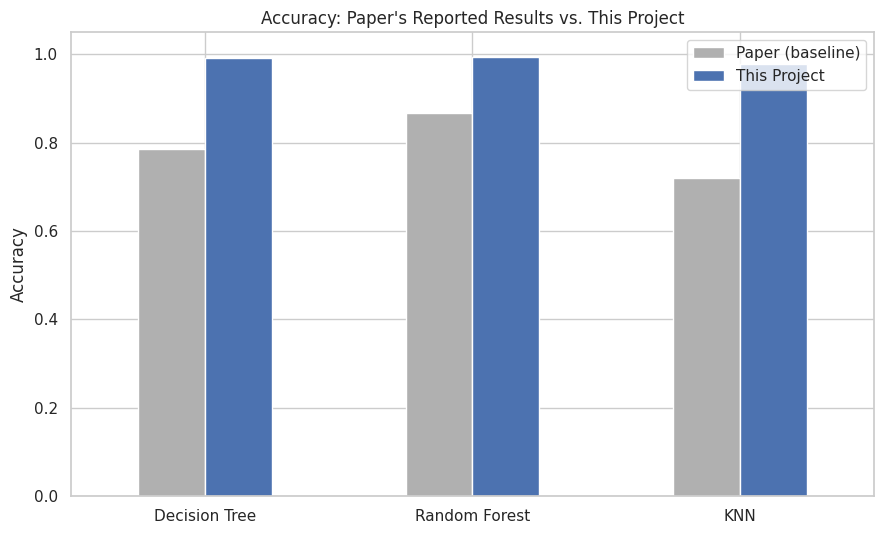

,Paper (baseline),This Project
Decision Tree,0.7867,0.9914
Random Forest,0.8667,0.9939
KNN,0.7205,0.9788


In [2]:
paper_results = pd.Series({"Decision Tree": 0.7867, "Random Forest": 0.8667, "KNN": 0.7205}, name="Paper (baseline)")
this_project = comparison["Accuracy"].rename("This Project")

acc_compare = pd.concat([paper_results, this_project], axis=1)

fig, ax = plt.subplots()
acc_compare.plot(kind="bar", ax=ax, color=["#B0B0B0", "#4C72B0"])
ax.set_title("Accuracy: Paper's Reported Results vs. This Project")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="")
plt.tight_layout()
plt.savefig("../reports/figures/27_accuracy_vs_paper.png", dpi=150)
plt.show()

acc_compare

## 2. Full Metric Comparison

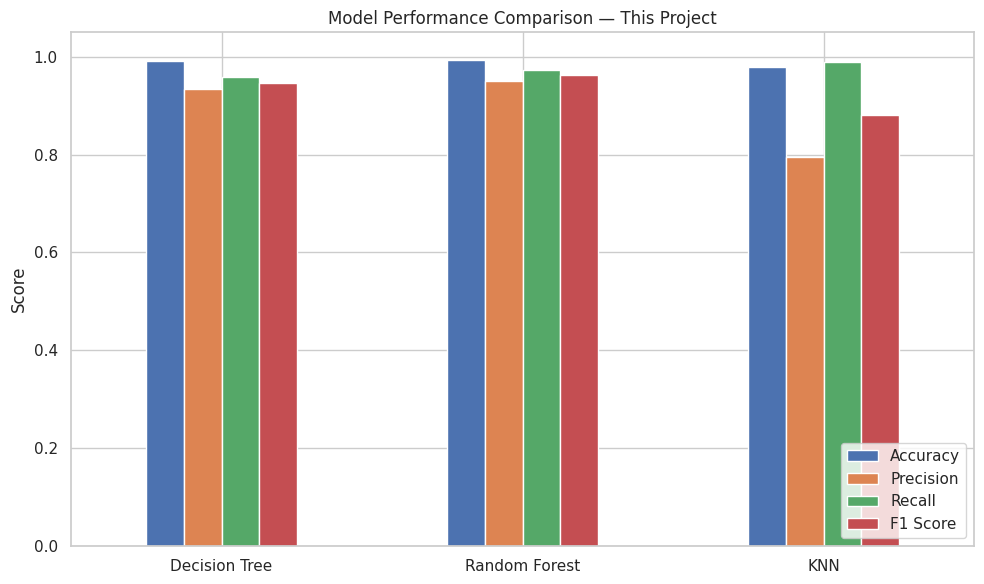

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))
comparison[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", ax=ax)
ax.set_title("Model Performance Comparison — This Project")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/figures/28_full_metric_comparison.png", dpi=150)
plt.show()

## 3. Confusion Matrices Side by Side

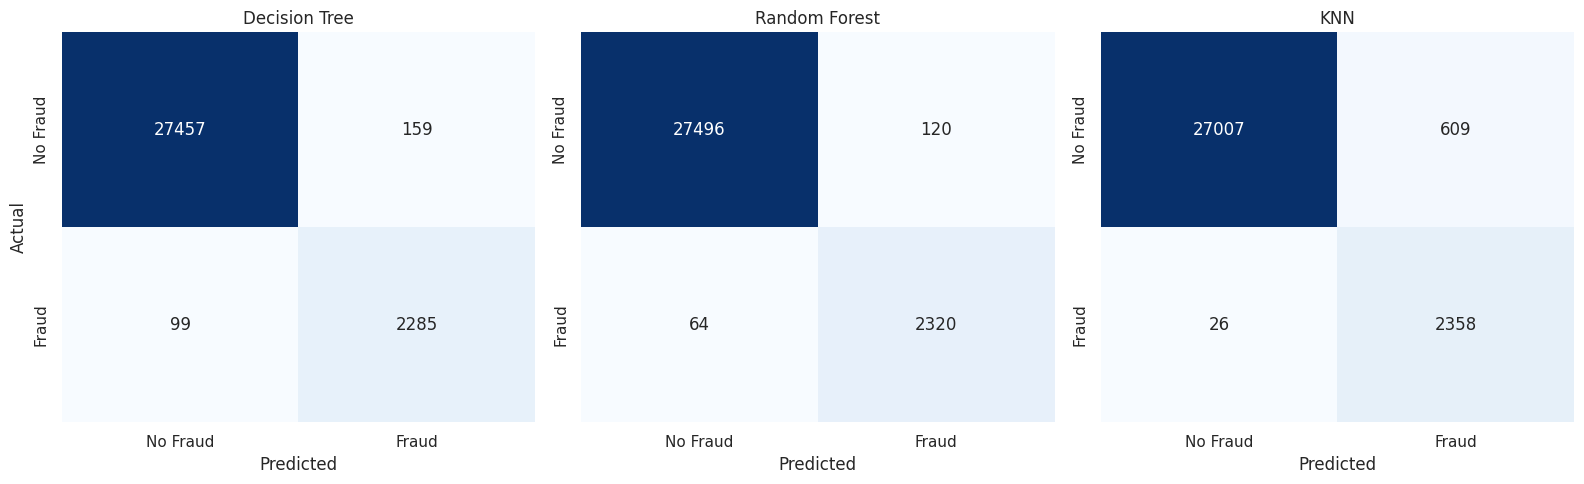

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, m) in zip(axes, all_metrics.items()):
    cm = m["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No Fraud", "Fraud"], yticklabels=["No Fraud", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if ax is axes[0] else "")

plt.tight_layout()
plt.savefig("../reports/figures/29_confusion_matrices_all.png", dpi=150)
plt.show()

## 4. ROC-AUC Comparison

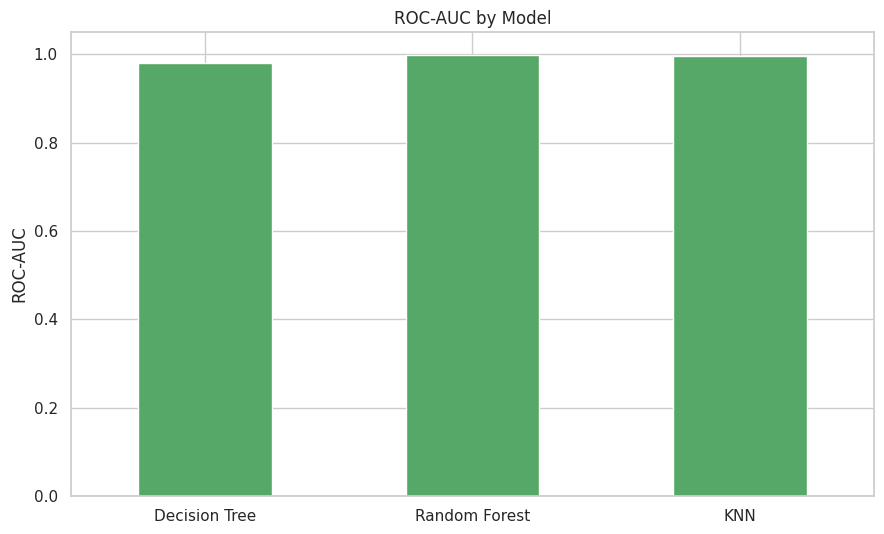

In [5]:
fig, ax = plt.subplots()
comparison["ROC-AUC"].plot(kind="bar", color="#55A868", ax=ax)
ax.set_title("ROC-AUC by Model")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/30_roc_auc_comparison.png", dpi=150)
plt.show()

In [6]:
best_model_name = comparison["F1 Score"].idxmax()
print(f"Best model by F1 score: {best_model_name}")
comparison.loc[[best_model_name]]

Best model by F1 score: Random Forest


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.9939,0.9508,0.9732,0.9619,0.999


## 5. Save Comparison Table

In [7]:
comparison.to_csv("../reports/metrics/model_comparison.csv")
print("Saved to reports/metrics/model_comparison.csv")

Saved to reports/metrics/model_comparison.csv
